# Problem Time P3

In [1]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *
from lib.animation_utils import *

mp.set_start_method("spawn", force=True)

VelField = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data.jld", steady=False)
CFG = TURB_TIME_P1.copy()

env = ZermeloEnv(CFG, VelField)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
best_policy = PolicyNet(obs_dim, act_dim)
best_policy.load_state_dict(torch.load("./saved_models/tp1.pth"))

<All keys matched successfully>

### Model Evaluation

Success probability : 1.0000
Mean success time: 0.6875


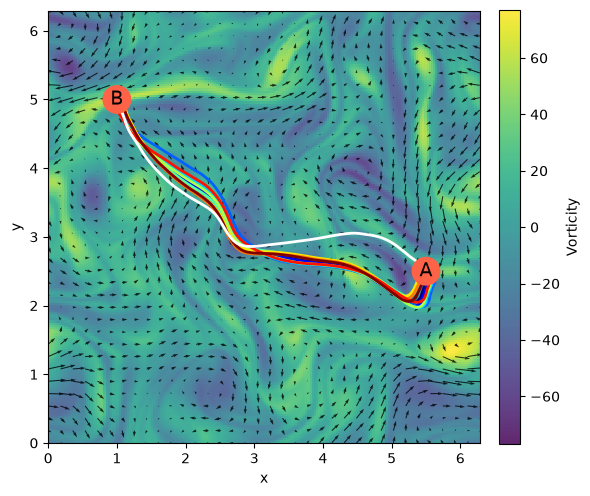

In [2]:
import h5py

env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=5000)

success_probability = np.mean([r["success"] for r in results])
mean_success_time = np.mean([r["time"] for r in results if r["success"]])

print(f"Success probability : {success_probability:.4f}")
print(f"Mean success time: {mean_success_time:.4f}")

track_opt = []
track_opt_v2 = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x_opt = f["x_tp1"]  # x_v, x2_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2, x2_tp1, x2_tp2
    y_opt = f["y_tp1"]
    x_opt_v2 = f["x2_tp1"]
    y_opt_v2 = f["y2_tp1"]
    track_opt = np.stack((x_opt, y_opt), axis=1)
    track_opt_v2 = np.stack((x_opt_v2, y_opt_v2), axis=1)

trajectories = [r["trajectory"] for r in results]
times = [r["time"] for r in results]
plot_trajectories(env, trajectories[0:10] + [track_opt], time=mean_success_time)

In [3]:
animation = make_animation(
    env=env,
    trajectories=trajectories[0:10]+[track_opt],
    dt=0.0070066242,
    dt_last=0.6700000231120774/len(track_opt),
    duration=15,
    filename="./figures/turb-p3.mp4",
)

Physical time: 0 ... 0.7287 s
Video duration: 15.00 s
FPS: 30
Frames: 450
Video dt: 0.001623 s
Saving video...
Saved: ./figures/turb-p3.mp4


Success probability : 1.0000
Mean success time: 0.6586


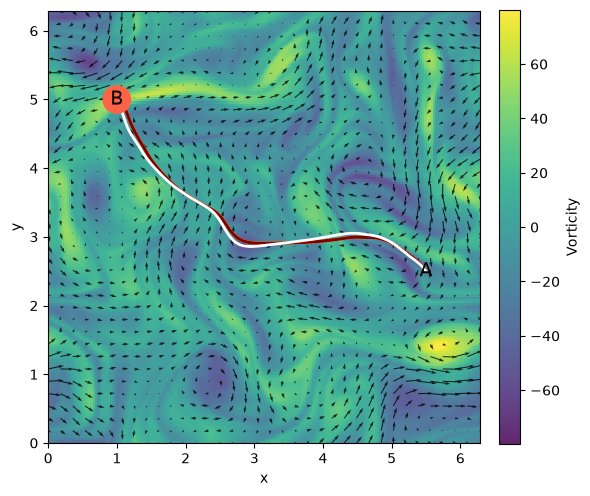

In [4]:
# exact starting position
CFG3 = TURB_TIME_P1.copy()
CFG3["rA"]=0.0001
CFG3["rB"]=0.2

best_policy_v2 = PolicyNet(obs_dim, act_dim)
best_policy_v2.load_state_dict(torch.load("./saved_models/tp1-v2.pth"))

env3 = ZermeloEnv(CFG3, VelField)
results3 = evaluate_policy(model=best_policy_v2, env=env3, n_eval=10)

success_probability3 = np.mean([r["success"] for r in results3])
mean_success_time3 = np.mean([r["time"] for r in results3 if r["success"]])

print(f"Success probability : {success_probability3:.4f}")
print(f"Mean success time: {mean_success_time3:.4f}")

trajectories3 = [r["trajectory"] for r in results3]
plot_trajectories(env3, trajectories3[0:10] + [track_opt], time=mean_success_time3)

# Problem Time P4

In [5]:
CFG2 = TURB_TIME_P2.copy()

env2 = ZermeloEnv(CFG2, VelField)
obs_dim = env2.observation_space.shape[0]
act_dim = env2.action_space.shape[0]
best_policy2 = PolicyNet(obs_dim, act_dim)
best_policy2.load_state_dict(torch.load("./saved_models/tp2.pth"))

<All keys matched successfully>

### Model Evaluation

Success probability : 1.0000
Mean success time: 0.6707


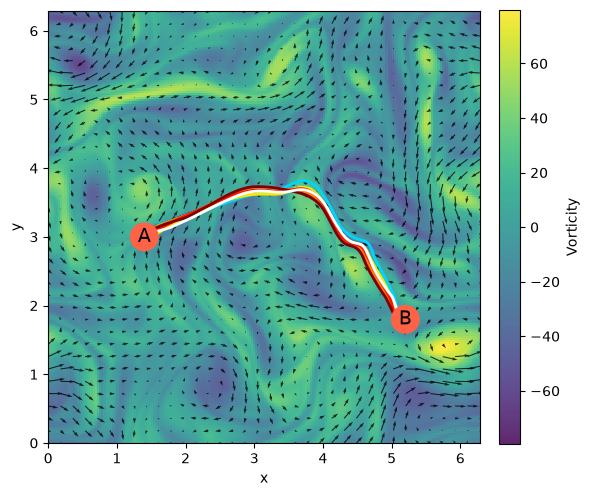

In [6]:
env2 = ZermeloEnv(CFG2, VelField)
results2 = evaluate_policy(model=best_policy2, env=env2, n_eval=5000)

success_probability2 = np.mean([r["success"] for r in results2])
mean_success_time2 = np.mean([r["time"] for r in results2 if r["success"]])

print(f"Success probability : {success_probability2:.4f}")
print(f"Mean success time: {mean_success_time2:.4f}")

track2_opt = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x2_opt = f["x_tp2"]  # x_v, x2_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2, x2_tp1, x2_tp2
    y2_opt = f["y_tp2"]
    track2_opt = np.stack((x2_opt, y2_opt), axis=1)

trajectories2 = [r["trajectory"] for r in results2]
times2 = [r["time"] for r in results2]
plot_trajectories(env2, trajectories2[0:10] + [track2_opt], time=mean_success_time2)

In [7]:
animation = make_animation(
    env=env2,
    trajectories=trajectories2[0:10]+[track2_opt],
    dt=0.0070066242,
    dt_last=0.7000008854088864/len(track_opt),
    duration=15,
    filename="./figures/turb-p4.mp4",
)

Physical time: 0 ... 0.7219 s
Video duration: 15.00 s
FPS: 30
Frames: 450
Video dt: 0.001608 s
Saving video...
Saved: ./figures/turb-p4.mp4


# Figure 7

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def plot_figure_7(env, env2, trajectories_A, trajectories_B, time_A, time_B, n_vort=200, n_vel=36, cmap="viridis"):
    fig, axes = plt.subplots(1, 2, figsize=(13.4, 6), constrained_layout=True)

    def plot_panel_A(ax):
        
        # Vorticity field
        x = np.linspace(env.x_min, env.x_max, n_vort)
        y = np.linspace(env.y_min, env.y_max, n_vort)
        X, Y = np.meshgrid(x, y)

        VORT = np.vectorize(env.vel_field.vort)(X, Y, time_A)
        vmax = np.max(np.abs(VORT))

        im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

        # Colorbar
        #cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        #cbar.ax.tick_params(labelsize=12)

        # Velocity field
        xq = np.linspace(env.x_min, env.x_max, n_vel)
        yq = np.linspace(env.y_min, env.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        U = np.vectorize(env.vel_field.velX)(Xq, Yq, time_A)
        V = np.vectorize(env.vel_field.velY)(Xq, Yq, time_A)

        ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

        # Trajectories
        colors = list(
            plt.cm.jet(
                np.linspace(0, 1, len(trajectories_A) - 12)
            )
        )
        colors = colors + ["magenta"]*10
        colors.append("white")

        for traj, color in zip(trajectories_A[:-1], colors):
            ax.plot(traj[:, 0], traj[:, 1], lw=3.5, color=color, zorder=3)
        ax.plot(trajectories_A[-1][:, 0], trajectories_A[-1][:, 1], lw=3.5, color="white", zorder=3, linestyle='--')
        
        ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))

        ax.text(env.xA, env.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
        ax.text(env.xB, env.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

        ax.text(0.82, 0.15, "P3", transform=ax.transAxes, fontsize=28, fontweight="bold", ha="center", va="center", color="white", zorder=10)

        time_text = ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=20, color="white", zorder=10)
        time_text.set_text(f"t = {time_A:.3f} s")

        # Formatting
        ax.set_xlim(env.x_min, env.x_max)
        ax.set_ylim(env.y_min, env.y_max)
        ax.set_aspect("equal")

        ax.set_xlabel("x", fontsize=32)
        ax.set_ylabel("y", fontsize=32)

        ax.set_xticks([0, 2, 4, 6])
        ax.set_yticks([0, 2, 4, 6])
        ax.tick_params(axis="both", which="major", labelsize=24)
        ax.grid(False)


    def plot_panel_B(ax):
        
        # Vorticity field
        x = np.linspace(env2.x_min, env2.x_max, n_vort)
        y = np.linspace(env2.y_min, env2.y_max, n_vort)
        X, Y = np.meshgrid(x, y)

        VORT = np.vectorize(env2.vel_field.vort)(X, Y, time_B)
        vmax = np.max(np.abs(VORT))

        im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

        # Colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("vorticity", fontsize=28)
        cbar.set_ticks([-70, -35, 0, 35, 70])
        cbar.ax.tick_params(labelsize=20)

        # Velocity field
        xq = np.linspace(env2.x_min, env2.x_max, n_vel)
        yq = np.linspace(env2.y_min, env2.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        U = np.vectorize(env2.vel_field.velX)(Xq, Yq, time_B)
        V = np.vectorize(env2.vel_field.velY)(Xq, Yq, time_B)

        ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

        # Trajectories
        colors = list(
            plt.cm.jet(
                np.linspace(0, 1, len(trajectories_B) - 1)
            )
        )
        colors.append("white")

        for traj, color in zip(trajectories_B, colors):
            ax.plot(traj[:, 0], traj[:, 1], lw=3.5, color=color, zorder=3)

        ax.add_patch(plt.Circle((env2.xA, env2.yA), env2.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env2.xB, env2.yB), env2.rB, color="tomato", alpha=1, zorder=4))

        ax.text(env2.xA, env2.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
        ax.text(env2.xB, env2.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

        ax.text(0.82, 0.15, "P4", transform=ax.transAxes, fontsize=28, fontweight="bold", ha="center", va="center", color="white", zorder=10)

        time_text = ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=20, color="white", zorder=10)
        time_text.set_text(f"t = {time_B:.3f} s")

        # Formatting
        ax.set_xlim(env2.x_min, env2.x_max)
        ax.set_ylim(env2.y_min, env2.y_max)
        ax.set_aspect("equal")

        ax.set_xlabel("x", fontsize=32)
        #ax.set_ylabel("y", fontsize=18)

        ax.set_xticks([0, 2, 4, 6])
        ax.set_yticks([0, 2, 4, 6])
        ax.tick_params(axis="both", which="major", labelsize=24)
        ax.grid(False)

        
    # ---------------------------------------------------------
    # Plot panels A and B
    # ---------------------------------------------------------
    plot_panel_A(axes[0])
    plot_panel_B(axes[1])
    
    plt.savefig("./figures/fig7.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0)

    plt.show()
    plt.close(fig)

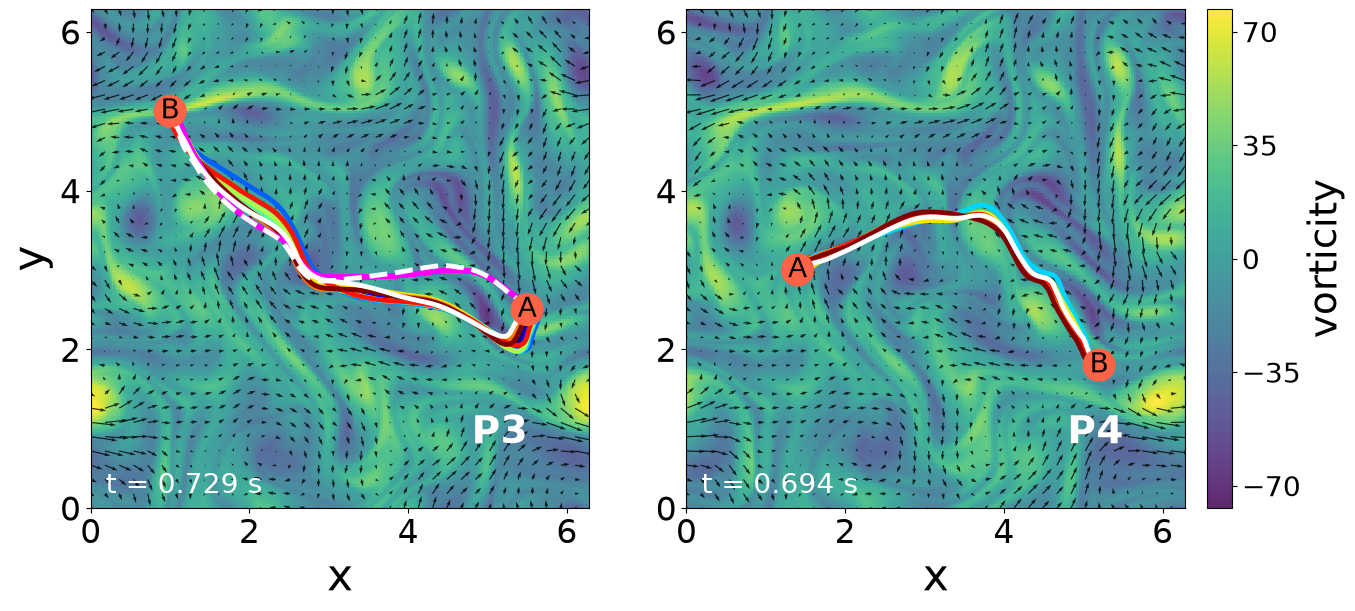

In [18]:
plot_figure_7(env, env2, trajectories[0:10] + trajectories3[0:10] + [track_opt_v2] + [track_opt],
              trajectories2[0:10] + [track2_opt], 
              max(times[0:10]), max(times2[0:10]))